In [1]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

cwd = Path.cwd()
CSV_PATH = cwd.parent.parent / "tests" / "parameter_grid_neural_net_tests_5000_epochs.csv"

In [2]:
df = pd.read_csv(CSV_PATH)
df.head(5)

,trial_num,total_parameters,hidden_layer_sizes,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y
0,1,1387,[],3.398301,4.863968,1.843448,2.205441,-47.6234,-62.9805,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.5723544359207153, 0.5483139157295227, -14.6...","[0.7901999950408936, 0.0538799986243248, 0.253...","[1.077474594116211, -0.08376902341842651, 0.79..."
1,2,2791,"[2, 4]",0.019706,0.022187,0.140379,0.148952,0.7180,0.7082,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.17283086478710175, 0.3033718764781952, 0.03...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6611942052841187, 0.14806047081947327, 0.22..."
2,3,2867,"[2, 4, 8, 4]",0.004318,0.004715,0.065708,0.068664,0.9382,0.9380,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2844669818878174, 0.33897697925567627, 0.06...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7341203689575195, 0.0649353563785553, 0.345..."
3,4,3011,"[2, 4, 16, 8]",0.022470,0.026143,0.149899,0.161688,0.6785,0.6561,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.21342025697231293, 0.27936995029449463, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.625963568687439, 0.08010832965373993, 0.625..."
4,5,3187,"[2, 4, 8, 8, 16, 8]",0.002741,0.002970,0.052353,0.054500,0.9608,0.9609,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.230343759059906, 0.2999867796897888, 0.0656...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7538678646087646, 0.06564795225858688, 0.28..."


In [3]:
def string_to_float_array(s):
    return np.array(ast.literal_eval(s), dtype=float)

In [4]:
df["train_y"] = df["train_y"].apply(string_to_float_array)
df["train_model_y"] = df["train_model_y"].apply(string_to_float_array)
df["test_y"] = df["test_y"].apply(string_to_float_array)
df["test_model_y"] = df["test_model_y"].apply(string_to_float_array)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df.dtypes

trial_num               int64
total_parameters        int64
hidden_layer_sizes        str
train_MSE             float64
test_MSE              float64
train_RMSE            float64
test_RMSE             float64
train_r2_score        float64
test_r2_score         float64
train_y                object
train_model_y          object
test_y                 object
test_model_y           object
dtype: object

In [7]:
def plot_scatter_with_fit(ax, x, y):
    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # y = x reference line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.6, label="ideal: y=x")

    ax.legend()

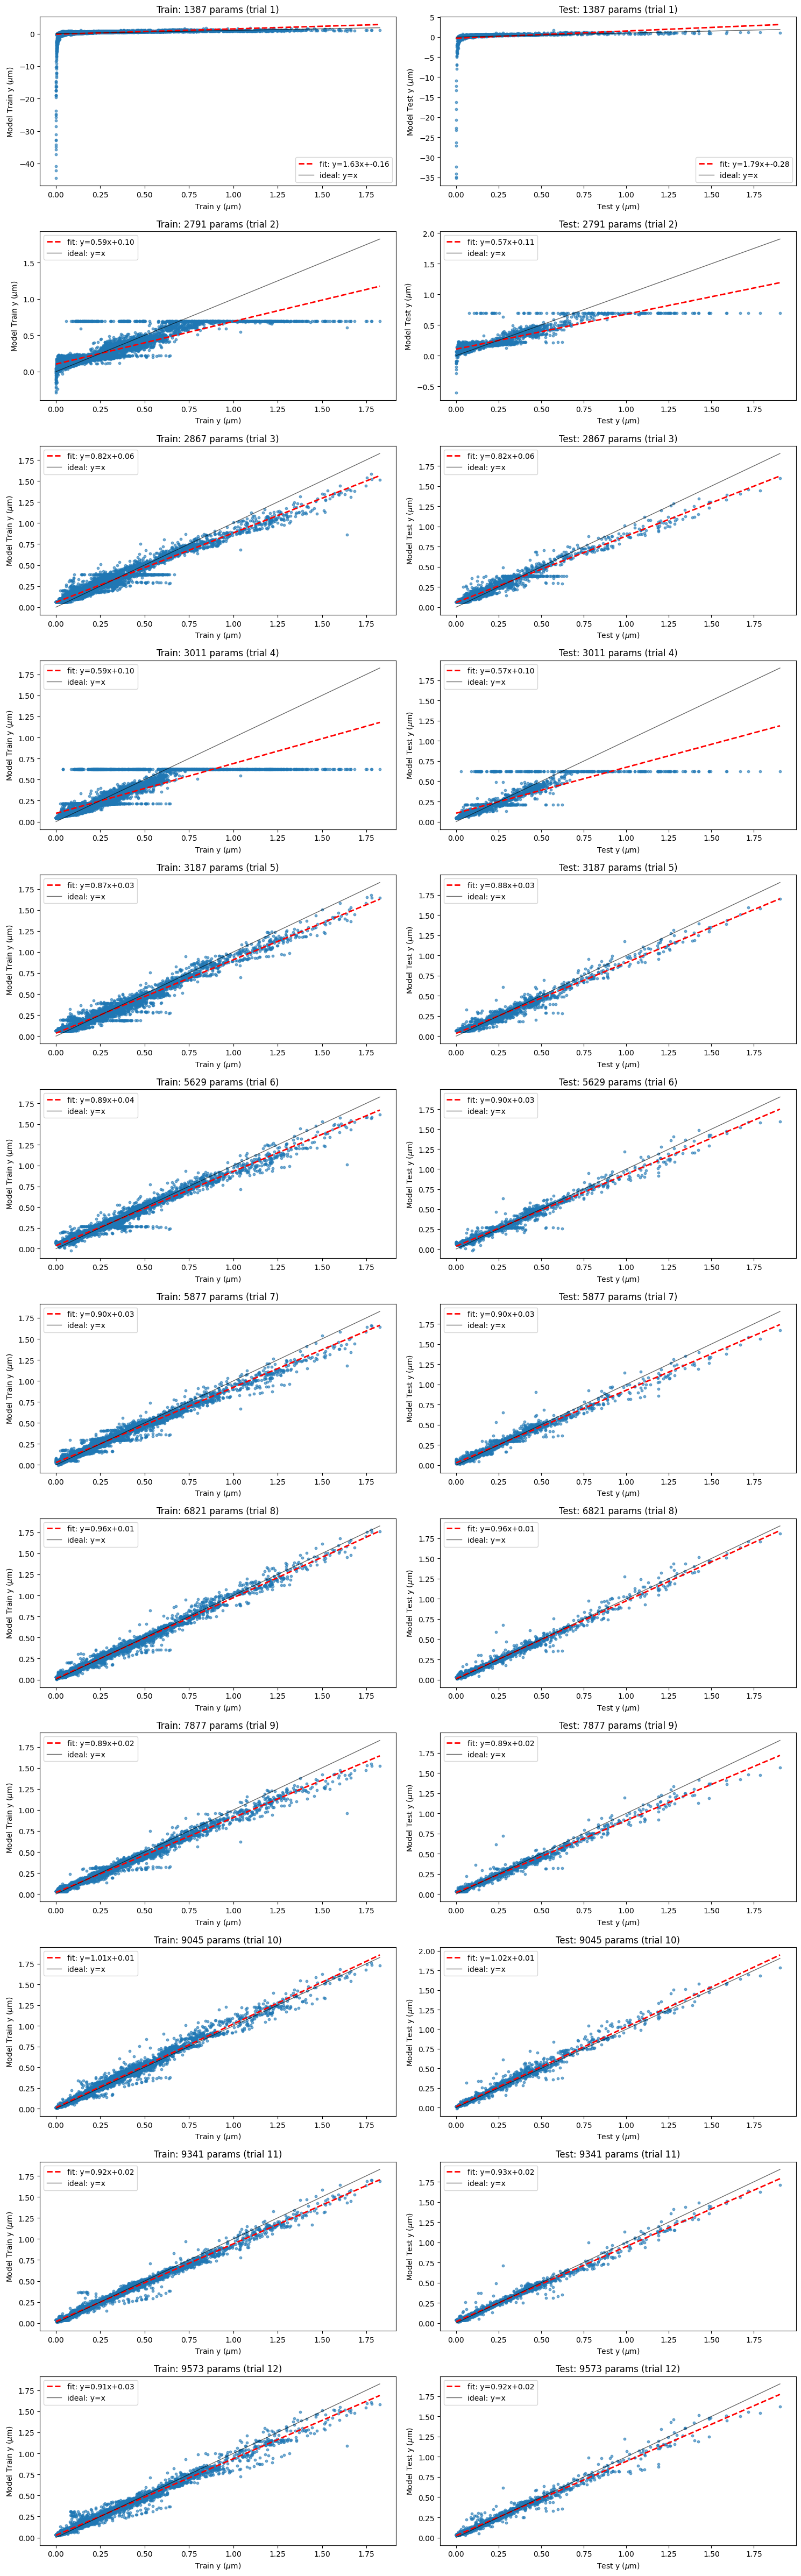

In [8]:
fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
axes = np.atleast_2d(axes)

for i, row in df.reset_index(drop=True).iterrows():
    x_tr = np.asarray(row["train_y"], dtype=float)
    y_tr = np.asarray(row["train_model_y"], dtype=float)
    x_te = np.asarray(row["test_y"], dtype=float)
    y_te = np.asarray(row["test_model_y"], dtype=float)

    plot_scatter_with_fit(axes[i, 0], x_tr, y_tr)
    axes[i, 0].set_title(f'Train: {row["total_parameters"]} params (trial {row["trial_num"]})')
    axes[i, 0].set_xlabel(r"Train y ($\mu$m)")
    axes[i, 0].set_ylabel(r"Model Train y ($\mu$m)")

    plot_scatter_with_fit(axes[i, 1], x_te, y_te)
    axes[i, 1].set_title(f'Test: {row["total_parameters"]} params (trial {row["trial_num"]})')
    axes[i, 1].set_xlabel(r"Test y ($\mu$m)")
    axes[i, 1].set_ylabel(r"Model Test y ($\mu$m)")

plt.tight_layout()
plt.show()